# Notebook for project

add all imports ill need

In [2]:
# tensorflow for model
import tensorflow as tf 

# numpy and matplotlib for data manipulation and visualization
import numpy as np
import matplotlib.pyplot as plt

# os for file handling
import os

from sklearn.metrics import f1_score, classification_report

import pandas as pd

import matplotlib.image as mpimg

from tensorflow.keras import layers

2026-04-19 01:10:42.996069: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-19 01:10:43.002787: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776557443.011843  195474 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776557443.014505  195474 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-19 01:10:43.022886: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

verify my gpu is actually being used so training is fast

In [3]:
print("GPUs available: ", tf.config.list_physical_devices('GPU'))

GPUs available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


now prevent tensorflow from grabbing all gpu memory to be on the safe side and nothing crashes 

In [4]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

# Data Exploration

Garbage classification
- 10 categories: metal, glass, biological, paper, battery, trash, cardboard, shoes, clothes, and plastic.
- All images are 384 × 384 pixels and in colour.

look inside the data folder to confirm categories

In [5]:
os.listdir('garbage')

['clothes',
 'shoes',
 'battery',
 'cardboard',
 'glass',
 'trash',
 'paper',
 'biological',
 'plastic',
 'metal']

ok now lets look at the class distribution and see what we are dealing with

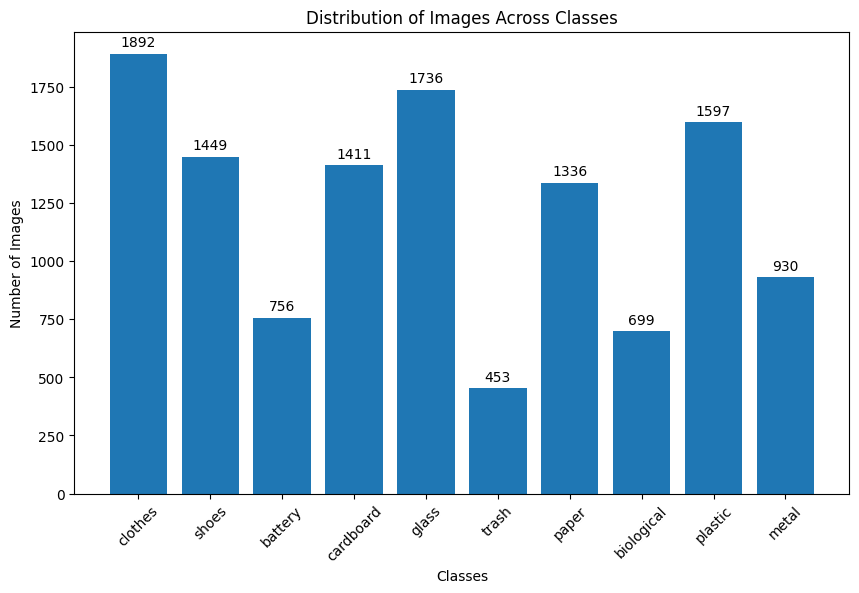

In [6]:
class_counts = {}
data_dir = 'garbage'

for folder in os.listdir(data_dir):
    path = os.path.join(data_dir, folder) 
    if os.path.isdir(path):
        class_counts[folder] = len(os.listdir(path))

plt.figure(figsize=(10, 6))
bars = plt.bar(class_counts.keys(), class_counts.values())
plt.bar_label(bars, padding=3) 
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.title('Distribution of Images Across Classes')
plt.xticks(rotation=45)
plt.show()

looking at the above plot we can clearly see the dataset is imbalanced. The clothes folder has the most images at 1892 and the trash folder has the least images at 453.

As stated in the brief **"If classes are not evenly represented, accuracy alone is a misleading metric - a model that simply predicts the majority class will achieve high accuracy while being useless. Use precision, recall, and F1-score on a per-class basis, and report the macro-averaged F1-score as your primary comparison metric across models, as it treats all classes equally regardless of their size."**

It also states **"an appropriate response to class imbalance in image classification is class weighting, which penalises
misclassification of minority classes more heavily during training. Keras supports this directly via the
class weight argument to model.fit(). The weights can be computed from the file counts in each class
directory before the dataset is loaded."**

so now we will do the class weighting which basically tells the model to pay more attention to the underrepresented classes like trash and not to focus on classes like clothes. 

get the class names in alphabetical order

In [7]:
class_names = sorted(class_counts.keys())
print("Class names:", class_names)

Class names: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


calculate the total number of images

In [8]:
total_samples = sum(class_counts.values())
num_classes = len(class_counts)

print("Total samples:", total_samples)
print("Number of classes:", num_classes)

Total samples: 12259
Number of classes: 10


compute the weights

In [9]:
class_weight = {}

for i, class_name in enumerate(class_names):
    count = class_counts[class_name]
    weight = total_samples / (num_classes * count)
    class_weight[i] = weight
    print(f"Class: {class_name}, Count: {count}, Weight: {weight:.4f}")

Class: battery, Count: 756, Weight: 1.6216
Class: biological, Count: 699, Weight: 1.7538
Class: cardboard, Count: 1411, Weight: 0.8688
Class: clothes, Count: 1892, Weight: 0.6479
Class: glass, Count: 1736, Weight: 0.7062
Class: metal, Count: 930, Weight: 1.3182
Class: paper, Count: 1336, Weight: 0.9176
Class: plastic, Count: 1597, Weight: 0.7676
Class: shoes, Count: 1449, Weight: 0.8460
Class: trash, Count: 453, Weight: 2.7062


ok class weights sorted for future use. Now moving on to next part of data exploration, lets take a sample image from each category, check the dimensions and check the min/max pixels. Then print each of the images. 

Category        | Dimensions      | Min/Max Pixels
--------------------------------------------------
battery         | (384, 384, 3)   | 0/255
biological      | (384, 384, 3)   | 0/255
cardboard       | (384, 384, 3)   | 0/255
clothes         | (384, 384, 3)   | 3/255
glass           | (384, 384, 3)   | 40/194
metal           | (384, 384, 3)   | 0/255
paper           | (384, 384, 3)   | 26/255
plastic         | (384, 384, 3)   | 0/255
shoes           | (384, 384, 3)   | 0/255
trash           | (384, 384, 3)   | 0/255


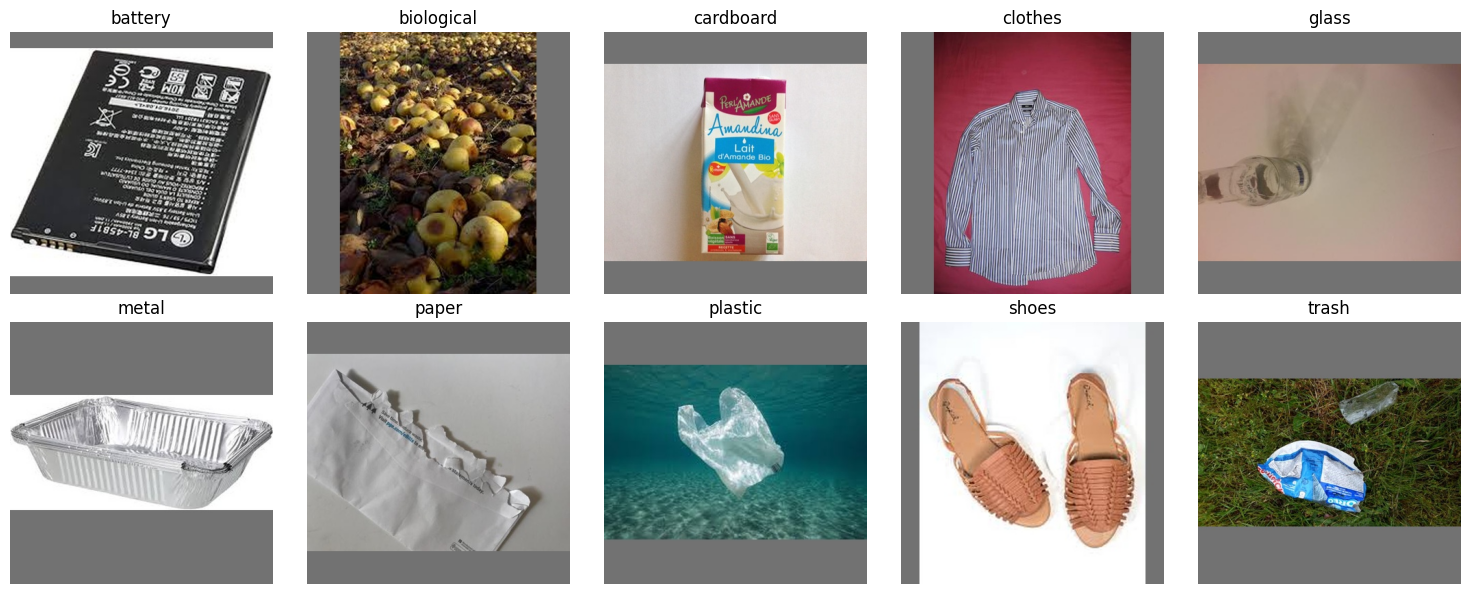

In [10]:
print(f"{'Category':<15} | {'Dimensions':<15} | {'Min/Max Pixels'}")
print("-" * 50)

plt.figure(figsize=(15, 6))

for i, category in enumerate(class_names):
    folder_path = os.path.join(data_dir, category)
    first_img_path = os.path.join(folder_path, os.listdir(folder_path)[0])
    img = mpimg.imread(first_img_path)
    
    stats = f"{img.min()}/{img.max()}"
    print(f"{category:<15} | {str(img.shape):<15} | {stats}")
    
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"{category}")
    plt.axis('off')

plt.tight_layout()
plt.show()

the 10 images we looked at all have the same sizing 384, 384, 3 so we shouldnt need to worry about resizing errors due to native 384x384 and fits in vRAM and VGG16 compatible. 

The pixel values are mostly 0/255 but some are not like glass 40/194 so we will need to use normalisation 

eda is now complete, I looked at the class distribution, sample images, image dimensions and the pixel value range. 

# Preprocessing and Splits

lets set the seed, image size and the batch size now. I'll use batch size 32 since it is the industry standard starting point and we have used it in labs. 

In [11]:
SEED = 373167
IMG_SIZE = (384, 384)
BATCH_SIZE = 32

dataset is split into training and holdout, training is shuffled to improve learning while the holdout is set to fixed order for a stable evaluation. 

In [12]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

Found 12259 files belonging to 10 classes.
Using 8582 files for training.


I0000 00:00:1776557489.299051  195474 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8172 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080, pci bus id: 0000:01:00.0, compute capability: 8.9


In [ ]:
holdout_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

Found 12259 files belonging to 10 classes.
Using 3677 files for validation.


optimisation, ensures the images are read from disk once 

In [14]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
holdout_ds = holdout_ds.cache().prefetch(AUTOTUNE)

need 20% test and 10% validation

In [15]:
holdout_ds_batches = tf.data.experimental.cardinality(holdout_ds)

test_ds = holdout_ds.take((2 * holdout_ds_batches) // 3)

val_ds = holdout_ds.skip((2 * holdout_ds_batches) // 3)

now prefetch which keeps the gpu busy by preparing the next batch while current batch is being processed

In [16]:
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print(f"Training batches: {len(train_ds)}, Val batches: {len(val_ds)}, Test batches: {len(test_ds)}")

Training batches: 269, Val batches: 39, Test batches: 76


now before training the models, I will set up early stopping and callback so that each model gets the same epochs and training is more fair

In [17]:
def get_callbacks():                                                                                                                                                                                         
    return [tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1                                                                                                                                 
    )]  

set the number of epochs to 50 for all models to use

In [18]:
EPOCHS = 50

# CNN models 

## Model 1

starting with a simple model with NO dropout, batch norm etc. Note im not using flatten, i am using global average 2d so that we do not have millions of parameters

In [65]:
model_v1 = tf.keras.Sequential([
    tf.keras.Input(shape=(384, 384, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_v1.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 382, 382, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 191, 191, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 189, 189, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 94, 94, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,202 (94.54 KB)

 Trainable params: 24,202 (94.54 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model_v1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
%%time
history_v1 = model_v1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS, 
    class_weight=class_weight,
    callbacks=get_callbacks()
)

Epoch 1/50


I0000 00:00:1776540961.606468   95431 service.cc:148] XLA service 0x78b90821d5b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776540961.606492   95431 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4080, Compute Capability 8.9
2026-04-18 20:36:01.749091: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776540962.001547   95431 cuda_dnn.cc:529] Loaded cuDNN version 91002


  5/269 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.1053 - loss: 2.5200

I0000 00:00:1776540965.445239   95431 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


269/269 ━━━━━━━━━━━━━━━━━━━━ 22s 67ms/step - accuracy: 0.1387 - loss: 2.1964 - val_accuracy: 0.2032 - val_loss: 2.1256
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.2386 - loss: 2.0504 - val_accuracy: 0.3020 - val_loss: 1.9952
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.3140 - loss: 1.9212 - val_accuracy: 0.3133 - val_loss: 1.9420
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.3464 - loss: 1.8324 - val_accuracy: 0.3486 - val_loss: 1.8624
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.3633 - loss: 1.7694 - val_accuracy: 0.3727 - val_loss: 1.8070
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.3806 - loss: 1.7242 - val_accuracy: 0.3815 - val_loss: 1.7508
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.3919 - loss: 1.6875 - val_accuracy: 0.3823 - val_loss: 1.7271
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.4013 - loss: 1.6577 - val_accuracy: 0.40

plot the training and validation

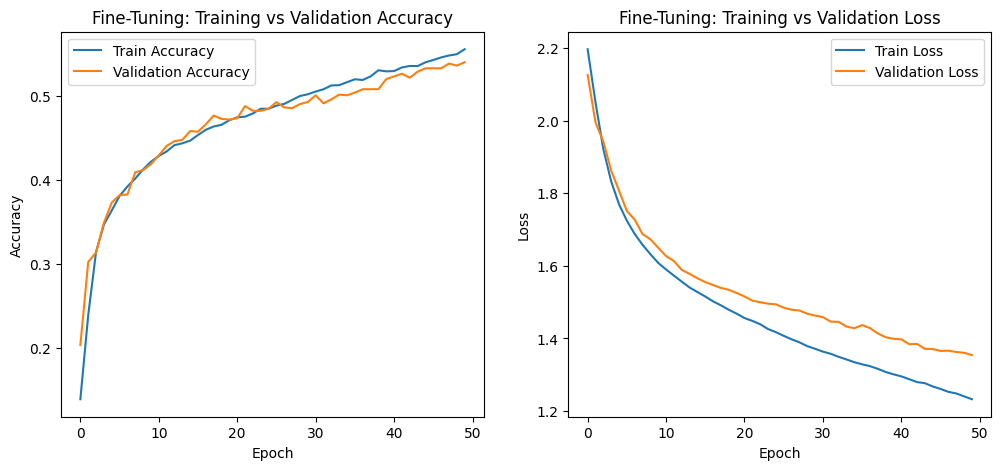

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_v1.history['accuracy'], label='Train Accuracy')
plt.plot(history_v1.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model 1: Training vs Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_v1.history['loss'], label='Train Loss')
plt.plot(history_v1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model 1: Training vs Validation Loss')
plt.legend()
plt.show()


now check the classification report and macro f1 

In [22]:
results_v1 = model_v1.evaluate(val_ds)
print(f"Validation Loss: {results_v1[0]:.4f}, Validation Accuracy: {results_v1[1]:.4f}")

y_true = []
y_pred = []
for images, labels in val_ds:
    preds = model_v1.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
print(classification_report(y_true, y_pred, target_names=class_names))

macro_f1_v1 = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score: {macro_f1_v1:.4f}")


39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5398 - loss: 1.3541
Validation Loss: 1.3541, Validation Accuracy: 0.5398
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

2026-04-18 20:58:48.024081: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Model 1 with basic architecture did not trigger early stopping and hit the final epoch of 50. So the model was still learning however its clearly underfitting to the data with very low accuracy. 

Validation accuracy 54% and the macro f1 0.5375.

Total train time was 7min 33s

Model seems to be struggling on classes like metal, glass, shoes and paper and its strongest class seems to be battery.
Can see that clothes has the highest recall but low precision so the model seems to over predict it. 

Overall result is that the model is underfitting which was to be expected since it was basic. 

## Model 2

Since the basic model underfits, it makes sense to add more conv blocks and more filters to allow the model to have more capacity when predicting. 

Same model just deeper, instead of 2 conv blocks I have added 4 

In [64]:
model_v2 = tf.keras.Sequential([
    tf.keras.Input(shape=(384, 384, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_v2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 382, 382, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 191, 191, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 189, 189, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 94, 94, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 92, 92, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 46, 46, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 44, 44, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 405,514 (1.55 MB)

 Trainable params: 405,514 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
%%time
history_v2 = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS, 
    class_weight=class_weight,
    callbacks=get_callbacks()
)

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - accuracy: 0.1563 - loss: 2.1715 - val_accuracy: 0.2289 - val_loss: 2.0668
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.3027 - loss: 1.9231 - val_accuracy: 0.2819 - val_loss: 2.0458
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.3823 - loss: 1.7386 - val_accuracy: 0.3839 - val_loss: 1.7719
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.4282 - loss: 1.6163 - val_accuracy: 0.4177 - val_loss: 1.6684
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.4685 - loss: 1.5024 - val_accuracy: 0.4402 - val_loss: 1.6039
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.4956 - loss: 1.4233 - val_accuracy: 0.4795 - val_loss: 1.4746
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.5213 - loss: 1.3546 - val_accuracy: 0.5221 - val_loss: 1.4122
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.5495 - loss: 1.2837 - 

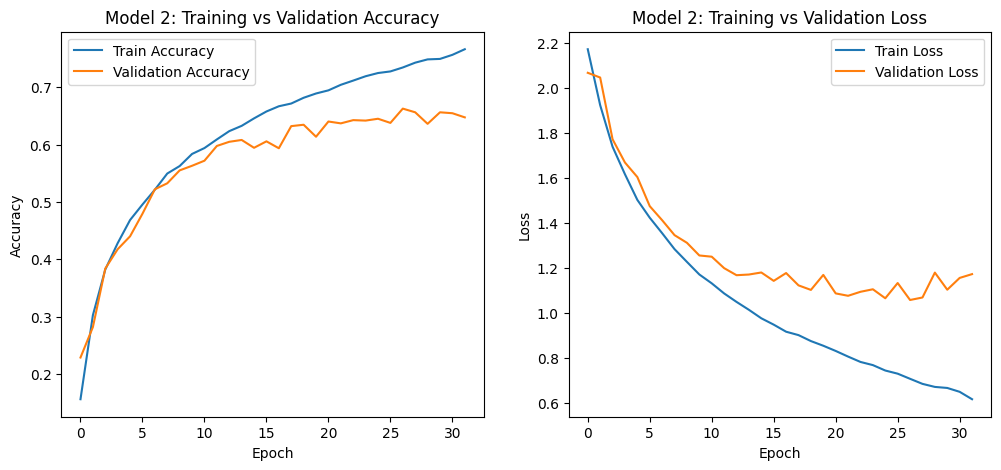

In [32]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_v2.history['accuracy'], label='Train Accuracy')
plt.plot(history_v2.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model 2: Training vs Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_v2.history['loss'], label='Train Loss')
plt.plot(history_v2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model 2: Training vs Validation Loss')
plt.legend()
plt.show()


In [33]:
results_v2 = model_v2.evaluate(val_ds)
print(f"Validation Loss: {results_v2[0]:.4f}, Validation Accuracy: {results_v2[1]:.4f}")

y_true = []
y_pred = []
for images, labels in val_ds:
    preds = model_v2.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
print(classification_report(y_true, y_pred, target_names=class_names))

macro_f1_v2 = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score: {macro_f1_v2:.4f}")


39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6627 - loss: 1.0580
Validation Loss: 1.0580, Validation Accuracy: 0.6627
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/ste

Early stopping was triggered at epoch 32, best epoch was at 27.  
Total training time was 6min 17s

val accuracy 66.3% , better than model 1. Macro f1 0.6524, also better than model 1. 

All classes improved from model 1, clothes has the highest recall of 0.88 with lower precision 0.61 which is similar to model 1 but not as extreme. 

So the overall result of adding more conv blocks improved the model but now it is clearly overfitting with train accuracy at 77% and val at 66%, val loss also started climbing after epoch 27 hence the early stop. So now after model 1 underfitting, we need to try and fix the overfitting from model 2. 

## Model 3

I am going to keep the 4 conv block setup we have since it improved the model but now add regularisation paramaters to try and address the overfitting. So this is now the deep model plus regularisation using Batch norm and dropout. 

Batch norm basically makes training faster and more stable but also has slight regularisation which can help with overfitting. Ill add it to each layer which will basically normalise the activations so the next layer doesnt have to deal with varying sclaes. This will hopefully help the model converge while getting better accuracy. 

Drop out adds noise which forces the model to learn robust patterns, this makes it harder for the model to just memorise items in the classes.

In [66]:
model_v3 = tf.keras.Sequential([
    tf.keras.Input(shape=(384, 384, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model_v3.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 382, 382, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 382, 382, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 191, 191, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 189, 189, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 189, 189, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 94, 94, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 92, 92, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 92, 92, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 46, 46, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 44, 44, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 44, 44, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,434 (1.55 MB)

 Trainable params: 406,474 (1.55 MB)

 Non-trainable params: 960 (3.75 KB)

In [35]:
model_v3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [36]:
%%time
history_v3 = model_v3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS, 
    class_weight=class_weight,
    callbacks=get_callbacks()
)

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.2392 - loss: 2.2905

2026-04-18 21:46:55.313160: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_1', 140 bytes spill stores, 140 bytes spill loads



269/269 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - accuracy: 0.2816 - loss: 2.0843 - val_accuracy: 0.1446 - val_loss: 2.8117
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.3676 - loss: 1.7784 - val_accuracy: 0.3912 - val_loss: 1.7332
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.4091 - loss: 1.6503 - val_accuracy: 0.3301 - val_loss: 1.8785
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.4394 - loss: 1.5625 - val_accuracy: 0.3743 - val_loss: 1.7927
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.4620 - loss: 1.4963 - val_accuracy: 0.3301 - val_loss: 2.0418
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.4931 - loss: 1.4193 - val_accuracy: 0.3357 - val_loss: 1.9757
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.5092 - loss: 1.3677 - val_accuracy: 0.4305 - val_loss: 1.6264
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.5278 - loss: 1.2984 - val_accurac

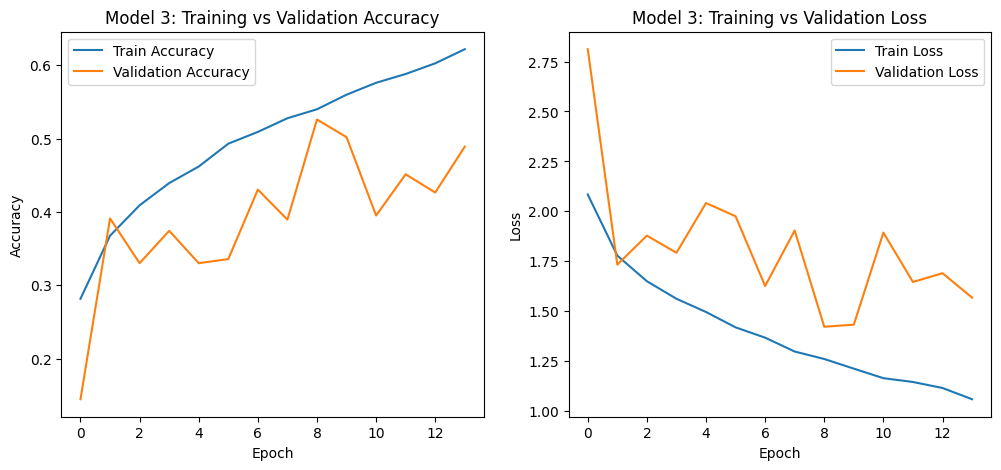

In [37]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_v3.history['accuracy'], label='Train Accuracy')
plt.plot(history_v3.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model 3: Training vs Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_v3.history['loss'], label='Train Loss')
plt.plot(history_v3.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model 3: Training vs Validation Loss')
plt.legend()
plt.show()


In [38]:
results_v3 = model_v3.evaluate(val_ds)
print(f"Validation Loss: {results_v3[0]:.4f}, Validation Accuracy: {results_v3[1]:.4f}")

y_true = []
y_pred = []
for images, labels in val_ds:
    preds = model_v3.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
print(classification_report(y_true, y_pred, target_names=class_names))

macro_f1_v3 = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score: {macro_f1_v3:.4f}")


39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5261 - loss: 1.4223
Validation Loss: 1.4223, Validation Accuracy: 0.5261
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/ste

2026-04-18 21:50:30.067170: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Model 3 is now the worst model out of the 3 of them. It seems that using batchnorm + dropout is unstable and they interact poorly... perhaps this is because dropout zeros out neurons which shifts the activation distributions that batch norm is trying to normalise. 

Total time 3min 21s  
Best epoch 9 , val accuracy 52.6% 
early stopping triggered at epoch 14  

macro f1 was 0.5215. 


## Model 4

Since model 3 didnt go as planned, I will remove the dropout and see if batch norm on its own improves the model. 

In [67]:
model_v4 = tf.keras.Sequential([
    tf.keras.Input(shape=(384, 384, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_v4.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 382, 382, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 382, 382, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 191, 191, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 189, 189, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 189, 189, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 94, 94, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 92, 92, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 92, 92, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 46, 46, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 44, 44, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 44, 44, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,434 (1.55 MB)

 Trainable params: 406,474 (1.55 MB)

 Non-trainable params: 960 (3.75 KB)

In [40]:
model_v4.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
%%time
history_v4 = model_v4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS, 
    class_weight=class_weight,
    callbacks=get_callbacks()
)

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3559 - loss: 1.8454

2026-04-18 22:05:36.089915: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_1', 140 bytes spill stores, 140 bytes spill loads



269/269 ━━━━━━━━━━━━━━━━━━━━ 18s 61ms/step - accuracy: 0.4033 - loss: 1.6863 - val_accuracy: 0.1157 - val_loss: 3.3332
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - accuracy: 0.4840 - loss: 1.4260 - val_accuracy: 0.2691 - val_loss: 2.2122
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.5364 - loss: 1.2895 - val_accuracy: 0.3100 - val_loss: 2.3938
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.5784 - loss: 1.1778 - val_accuracy: 0.2562 - val_loss: 2.8851
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.6093 - loss: 1.0839 - val_accuracy: 0.2112 - val_loss: 3.5698
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.6423 - loss: 1.0025 - val_accuracy: 0.3221 - val_loss: 3.5782
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.6706 - loss: 0.9250 - val_accuracy: 0.4145 - val_loss: 1.9256
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.6932 - loss: 0.8558 - val_accurac

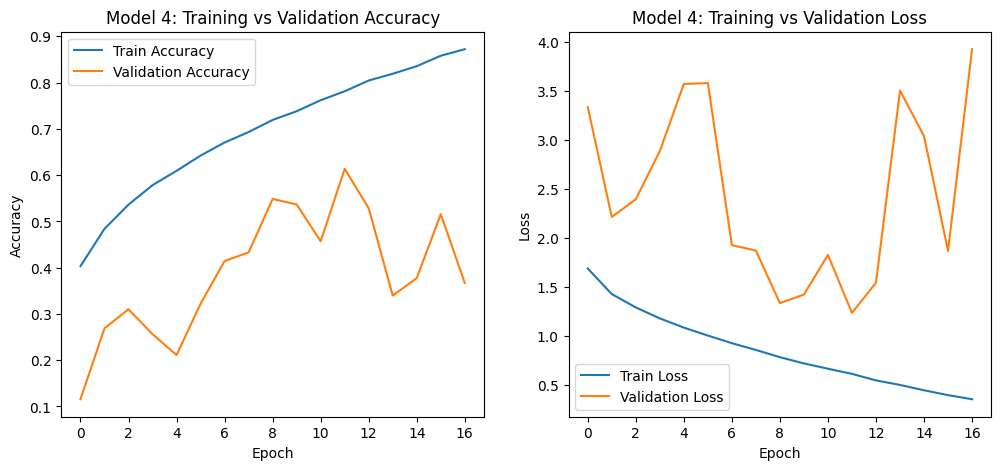

In [42]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_v4.history['accuracy'], label='Train Accuracy')
plt.plot(history_v4.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model 4: Training vs Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_v4.history['loss'], label='Train Loss')
plt.plot(history_v4.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model 4: Training vs Validation Loss')
plt.legend()
plt.show()


In [43]:
results_v4 = model_v4.evaluate(val_ds)
print(f"Validation Loss: {results_v4[0]:.4f}, Validation Accuracy: {results_v4[1]:.4f}")

y_true = []
y_pred = []
for images, labels in val_ds:
    preds = model_v4.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
print(classification_report(y_true, y_pred, target_names=class_names))

macro_f1_v4 = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score: {macro_f1_v4:.4f}")


39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6137 - loss: 1.2338
Validation Loss: 1.2338, Validation Accuracy: 0.6137
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/ste

early stopping at epoch 17
best epoch: 12. val accuracy 61.4% and macro f1 0.6054
Total time: 4min 3s

So deep model plus just batch norm was better than the previous model but not as good as model 2 (deep model). val loss seems fairly unstable again going between 1.23 and 3.92. BatchNorm doesnt seem to be working as I had hoped, perhaps the batch size is too small compared to the high res images. 

## Model 5

Since BatchNorm + deep did better than adding BatchNorm + dropout + deep, I will now try deep + dropout to see which improves the model the most. 

I will use the standard default after global average pooling which is dropout 0.5, this is where the model transitions from spatial features to classification and its the point with most risk of memorisation. 

then 0.3 dropout on the dense layer because it is lighter with only 64 neurons and i dont want to risk overdoing it on the classifier, 0.3 should give some regularisation here though. 

In [68]:
model_v5 = tf.keras.Sequential([
    tf.keras.Input(shape=(384, 384, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model_v5.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_6 (Rescaling)         │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 382, 382, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 191, 191, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 189, 189, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 94, 94, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 92, 92, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 46, 46, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 44, 44, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 405,514 (1.55 MB)

 Trainable params: 405,514 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
model_v5.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [46]:
%%time
history_v5 = model_v5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS, 
    class_weight=class_weight,
    callbacks=get_callbacks()
)

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - accuracy: 0.1303 - loss: 2.2138 - val_accuracy: 0.1767 - val_loss: 2.1770
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.2064 - loss: 2.0938 - val_accuracy: 0.2426 - val_loss: 2.0527
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.2584 - loss: 1.9958 - val_accuracy: 0.2851 - val_loss: 2.0001
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.3120 - loss: 1.8769 - val_accuracy: 0.3430 - val_loss: 1.8642
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.3444 - loss: 1.8025 - val_accuracy: 0.3727 - val_loss: 1.7741
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.3795 - loss: 1.7371 - val_accuracy: 0.4297 - val_loss: 1.6877
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.4148 - loss: 1.6494 - val_accuracy: 0.4707 - val_loss: 1.5580
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.4455 - loss: 1.5688 - 

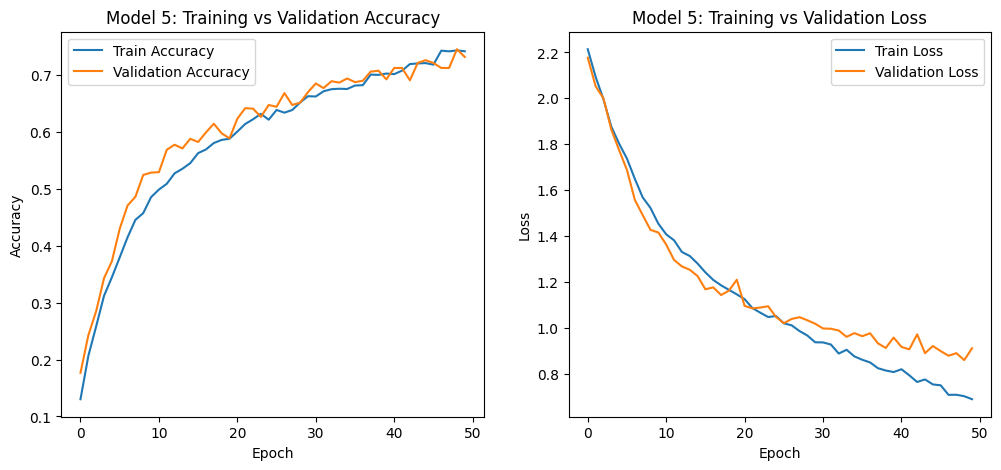

In [47]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_v5.history['accuracy'], label='Train Accuracy')
plt.plot(history_v5.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model 5: Training vs Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_v5.history['loss'], label='Train Loss')
plt.plot(history_v5.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model 5: Training vs Validation Loss')
plt.legend()
plt.show()


In [48]:
results_v5 = model_v5.evaluate(val_ds)
print(f"Validation Loss: {results_v5[0]:.4f}, Validation Accuracy: {results_v5[1]:.4f}")

y_true = []
y_pred = []
for images, labels in val_ds:
    preds = model_v5.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
print(classification_report(y_true, y_pred, target_names=class_names))

macro_f1_v5 = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score: {macro_f1_v5:.4f}")


39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7454 - loss: 0.8600
Validation Loss: 0.8600, Validation Accuracy: 0.7454
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/ste

Total time: 9min 55s

74.5% val accuracy and 0.74 macro f1, val loss looks smooth and stable compared to previous runs. 

early stopping did not get triggered, best epoch was 49 with val loss 0.86, epoch 50 was a bit worse at 0.91 but the val loss was still trending downward overall. More epochs could potentially improve it further.

all classes improved but metal and trash are still weakest but at 0.67. 

best model by a mile 

## Model 6

Now I will use model 5 but add data augmentation to it. Specifically random flip horizontal since most of the garbage items look the same flipped, random rotation 0.1 because slight tilts are normal in real photos, and random zoom 0.1 because images can be taken close or far away. 

In [70]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [71]:
model_v6 = tf.keras.Sequential([
    tf.keras.Input(shape=(384, 384, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model_v6.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 382, 382, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 191, 191, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 189, 189, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 94, 94, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 92, 92, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 46, 46, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 44, 44, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 405,514 (1.55 MB)

 Trainable params: 405,514 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
model_v6.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [52]:
%%time
history_v6 = model_v6.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS, 
    class_weight=class_weight,
    callbacks=get_callbacks()
)

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 16s 48ms/step - accuracy: 0.1236 - loss: 2.2239 - val_accuracy: 0.1486 - val_loss: 2.2023
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.1481 - loss: 2.1582 - val_accuracy: 0.1719 - val_loss: 2.1829
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.2120 - loss: 2.0799 - val_accuracy: 0.2627 - val_loss: 2.0431
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.2593 - loss: 1.9839 - val_accuracy: 0.3301 - val_loss: 1.9074
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.2973 - loss: 1.9168 - val_accuracy: 0.3301 - val_loss: 1.8583
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.3228 - loss: 1.8716 - val_accuracy: 0.3687 - val_loss: 1.7997
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.3531 - loss: 1.8183 - val_accuracy: 0.4072 - val_loss: 1.7289
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.3681 - loss: 1.7628 - 

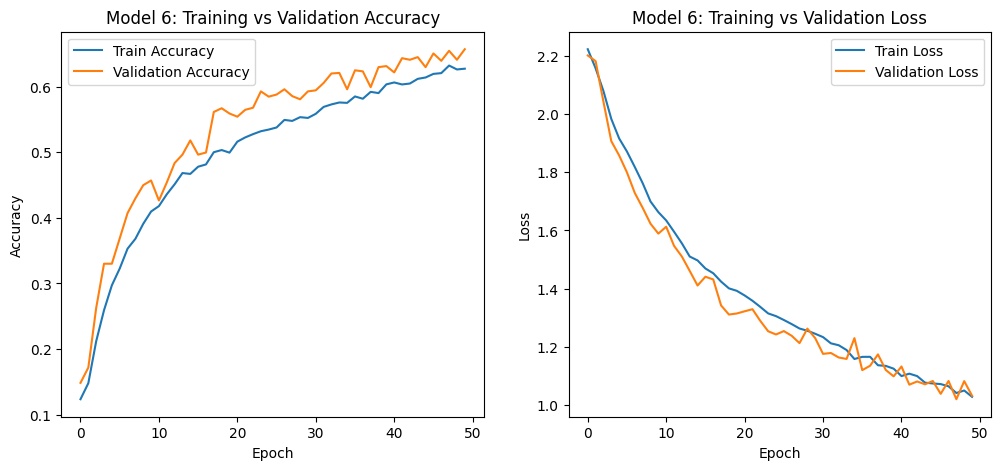

In [53]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_v6.history['accuracy'], label='Train Accuracy')
plt.plot(history_v6.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model 6: Training vs Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_v6.history['loss'], label='Train Loss')
plt.plot(history_v6.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model 6: Training vs Validation Loss')
plt.legend()
plt.show()


In [54]:
results_v6 = model_v6.evaluate(val_ds)
print(f"Validation Loss: {results_v6[0]:.4f}, Validation Accuracy: {results_v6[1]:.4f}")

y_true = []
y_pred = []
for images, labels in val_ds:
    preds = model_v6.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
print(classification_report(y_true, y_pred, target_names=class_names))

macro_f1_v6 = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score: {macro_f1_v6:.4f}")


39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6546 - loss: 1.0191
Validation Loss: 1.0191, Validation Accuracy: 0.6546
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

Total time: 10min 1s

the addition of data augmentation decreased the performance. perhaps too much regularization? train accuracy is lower than the val accuracy so theres a bit of underfitting going on now, model is getting held back rather than not memorising. 

val accuracy 65% and macro f1 0.6485

# Greyscale model using best scratch cnn model 5

In [19]:
train_ds_grey = tf.keras.utils.image_dataset_from_directory(                                                                                                                     
    data_dir,                                                                                                                                                                    
    validation_split=0.3,                                                                                                                                                        
    subset="training",                                                                                                                                                           
    seed=SEED,                                                                                                                                                                   
    image_size=IMG_SIZE,                                                                                                                                                         
    batch_size=BATCH_SIZE,                                                                                                                                                       
    shuffle=True,                                                                                                                                                                
    color_mode='grayscale',                                                                                                                                                      
)      

Found 12259 files belonging to 10 classes.
Using 8582 files for training.


In [20]:
holdout_ds_grey = tf.keras.utils.image_dataset_from_directory(                                                                                                                   
    data_dir,                                                                                                                                                                    
    validation_split=0.3,                                                                                                                                                        
    subset="validation",                                                                                                                                                       
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    color_mode='grayscale',
)   

Found 12259 files belonging to 10 classes.
Using 3677 files for validation.


In [21]:
holdout_ds_grey = holdout_ds_grey.cache().prefetch(AUTOTUNE)                                                                                                                     
train_ds_grey = train_ds_grey.cache().prefetch(AUTOTUNE)                                                                                                                       
                                                                                                                                                                                
holdout_ds_grey_batches = tf.data.experimental.cardinality(holdout_ds_grey)                                                                                                      
test_ds_grey = holdout_ds_grey.take((2 * holdout_ds_grey_batches) // 3).prefetch(AUTOTUNE)                                                                                       
val_ds_grey = holdout_ds_grey.skip((2 * holdout_ds_grey_batches) // 3).prefetch(AUTOTUNE) 

In [72]:
model_v5_grey = tf.keras.Sequential([
    tf.keras.Input(shape=(384, 384, 1)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model_v5_grey.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_8 (Rescaling)         │ (None, 384, 384, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 382, 382, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 191, 191, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 189, 189, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 94, 94, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 92, 92, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 46, 46, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 44, 44, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,938 (1.54 MB)

 Trainable params: 404,938 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model_v5_grey.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
%%time
history_v5_grey = model_v5_grey.fit(
    train_ds_grey,
    validation_data=val_ds_grey,
    epochs=EPOCHS, 
    class_weight=class_weight,
    callbacks=get_callbacks()
)

Epoch 1/50


I0000 00:00:1776559627.410467  199007 service.cc:148] XLA service 0x7690440018c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776559627.410485  199007 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4080, Compute Capability 8.9
2026-04-19 01:47:07.577444: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776559627.670719  199007 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/269 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.0764 - loss: 2.5392

I0000 00:00:1776559633.636003  199007 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


269/269 ━━━━━━━━━━━━━━━━━━━━ 30s 86ms/step - accuracy: 0.1235 - loss: 2.2749 - val_accuracy: 0.1655 - val_loss: 2.2495
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 62ms/step - accuracy: 0.1622 - loss: 2.1903 - val_accuracy: 0.1550 - val_loss: 2.2040
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - accuracy: 0.1684 - loss: 2.1533 - val_accuracy: 0.1992 - val_loss: 2.1448
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 62ms/step - accuracy: 0.1697 - loss: 2.1363 - val_accuracy: 0.2008 - val_loss: 2.1338
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 62ms/step - accuracy: 0.1820 - loss: 2.0815 - val_accuracy: 0.2289 - val_loss: 2.0807
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 65ms/step - accuracy: 0.2158 - loss: 2.0130 - val_accuracy: 0.2618 - val_loss: 2.0128
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - accuracy: 0.2261 - loss: 1.9615 - val_accuracy: 0.2562 - val_loss: 1.9740
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 16s 60ms/step - accuracy: 0.2321 - loss: 1.9332 - val_accurac

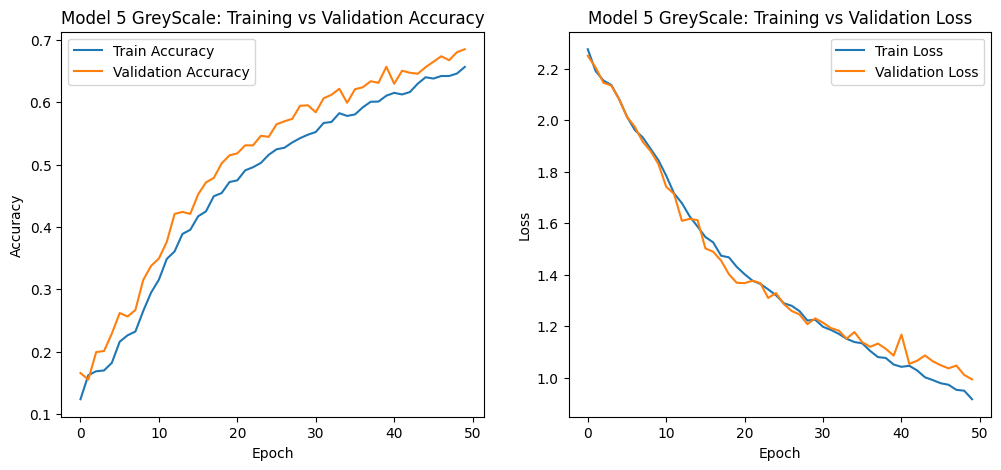

In [25]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_v5_grey.history['accuracy'], label='Train Accuracy')
plt.plot(history_v5_grey.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model 5 GreyScale: Training vs Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_v5_grey.history['loss'], label='Train Loss')
plt.plot(history_v5_grey.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model 5 GreyScale: Training vs Validation Loss')
plt.legend()
plt.show()


In [26]:
results_v5_grey = model_v5_grey.evaluate(val_ds_grey)
print(f"Validation Loss: {results_v5_grey[0]:.4f}, Validation Accuracy: {results_v5_grey[1]:.4f}")

y_true = []
y_pred = []
for images, labels in val_ds_grey:
    preds = model_v5_grey.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
print(classification_report(y_true, y_pred, target_names=class_names))

macro_f1_v5_grey = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score: {macro_f1_v5_grey:.4f}")


39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6851 - loss: 0.9939
Validation Loss: 0.9939, Validation Accuracy: 0.6851
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/ste

2026-04-19 02:01:48.264584: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Total time: 14min 5s

early stopping didnt trigger so model was still improving slightly. 

val accuracy 68.5% and macro f1 0.6770

compared to rgb which got 74.5% val accuracy and 0.7443 macro f1. 

Model performs better on rgb images which makes sense since colour is a strong cue for identifying biological waste from plastic waste 

just to verify the images are in grey scale 

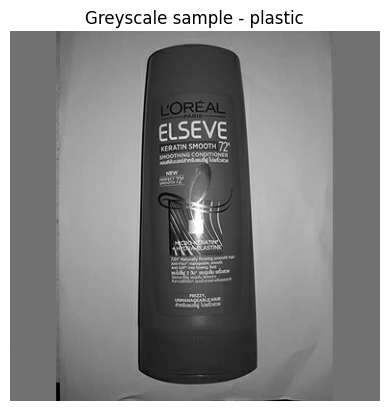

In [27]:
for images, labels in train_ds_grey.take(1):                                                                                                                                     
    plt.imshow(images[0].numpy().squeeze(), cmap='gray')                                                                                                                         
    plt.title(f"Greyscale sample - {class_names[labels[0]]}")
    plt.axis('off')                                                                                                                                                              
    plt.show()  
    break   

# Different image size on best model 

Ill use a smaller image size set at 224x224 to speed up training and see if my best model can perform well 

In [29]:
IMG_SIZE_DIFF = (224, 224)

In [30]:
train_ds_img_diff = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE_DIFF,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

holdout_ds_img_diff = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE_DIFF,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.


In [31]:
holdout_ds_img_diff = holdout_ds_img_diff.cache().prefetch(AUTOTUNE)                                                                                                             
train_ds_img_diff = train_ds_img_diff.cache().prefetch(AUTOTUNE)                                                                                                                 
                                                                                                                                                                                
holdout_ds_img_diff_batches = tf.data.experimental.cardinality(holdout_ds_img_diff)                                                                                              
test_ds_img_diff = holdout_ds_img_diff.take((2 * holdout_ds_img_diff_batches) // 3).prefetch(AUTOTUNE)                                                                           
val_ds_img_diff = holdout_ds_img_diff.skip((2 * holdout_ds_img_diff_batches) // 3).prefetch(AUTOTUNE) 

In [73]:
model_v5_img_size_diff = tf.keras.Sequential([
    tf.keras.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model_v5_img_size_diff.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_9 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 405,514 (1.55 MB)

 Trainable params: 405,514 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model_v5_img_size_diff.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [34]:
%%time
history_v5_img_size_diff = model_v5_img_size_diff.fit(
    train_ds_img_diff,
    validation_data=val_ds_img_diff,
    epochs=EPOCHS, 
    class_weight=class_weight,
    callbacks=get_callbacks()
)

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.1272 - loss: 2.2266 - val_accuracy: 0.1783 - val_loss: 2.1706
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.2171 - loss: 2.0885 - val_accuracy: 0.2956 - val_loss: 1.9855
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.2750 - loss: 1.9752 - val_accuracy: 0.2763 - val_loss: 1.9504
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3074 - loss: 1.8975 - val_accuracy: 0.3357 - val_loss: 1.8380
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3331 - loss: 1.8206 - val_accuracy: 0.3759 - val_loss: 1.7958
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3633 - loss: 1.7558 - val_accuracy: 0.3992 - val_loss: 1.6890
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3866 - loss: 1.6843 - val_accuracy: 0.4402 - val_loss: 1.5901
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4182 - loss: 1.6137 - val_acc

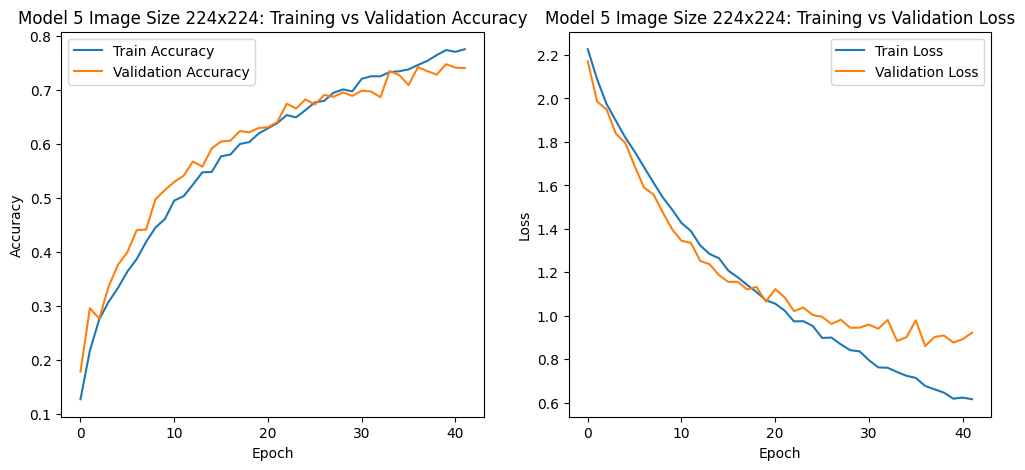

In [35]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_v5_img_size_diff.history['accuracy'], label='Train Accuracy')
plt.plot(history_v5_img_size_diff.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model 5 Image Size 224x224: Training vs Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_v5_img_size_diff.history['loss'], label='Train Loss')
plt.plot(history_v5_img_size_diff.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model 5 Image Size 224x224: Training vs Validation Loss')
plt.legend()
plt.show()


In [36]:
results_v5_img_size_diff = model_v5_img_size_diff.evaluate(val_ds_img_diff)
print(f"Validation Loss: {results_v5_img_size_diff[0]:.4f}, Validation Accuracy: {results_v5_img_size_diff[1]:.4f}")

y_true = []
y_pred = []
for images, labels in val_ds_img_diff:
    preds = model_v5_img_size_diff.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
print(classification_report(y_true, y_pred, target_names=class_names))

macro_f1_v5_img_size_diff = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score: {macro_f1_v5_img_size_diff:.4f}")


39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7414 - loss: 0.8608
Validation Loss: 0.8608, Validation Accuracy: 0.7414
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

2026-04-19 03:26:10.715146: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Total time: 3min 57s

close in accuracy to model on 384x384, so smaller images must lose minimal detail but train much faster in this dataset.

Early stopping was triggered at epoch 42 with best epoch at 37.

It was fitting nicely to the data for most of training but then started to slightly overfit again further into the epochs. 

Model at 224x224 74% val accuracy and 0.7333 macro f1  
Model at 383x384 74.5% val accuracy and 0.7443 macro f1



# Transfer learning

Ill be using VGG16 since it has a fairly straightforward archictecture and it was trained on ImageNet which includes everyday objects that would be similar to the items i have in the garbage dataset. Also the 224x224 input size nicely matches the image size I just tested so no need to duplicate more code. 

In [37]:
from tensorflow.keras.applications import VGG16                                                                                                                                  
from tensorflow.keras.applications.vgg16 import preprocess_input

In [38]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))                                                                                             
base_model.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [74]:
model_tl = tf.keras.Sequential([                                                                                                                                                 
    tf.keras.Input(shape=(224, 224, 3)),
    layers.Lambda(preprocess_input),                                                                                                                                             
    base_model,                                                                                                                                                                  
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),                                                                                                                                                         
    layers.Dense(64, activation='relu'),                                                                                                                                         
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')                                                                                                                                       
])

model_tl.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,748,170 (56.26 MB)

 Trainable params: 7,112,906 (27.13 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [40]:
model_tl.compile(                                                                                                                                                                
    optimizer='adam',                                                                                                                                                            
    loss='sparse_categorical_crossentropy',                                                                                                                                      
    metrics=['accuracy']                                                                                                                                                         
)  

In [41]:
%%time
history_tl = model_tl.fit(
    train_ds_img_diff,
    validation_data=val_ds_img_diff,
    epochs=EPOCHS, 
    class_weight=class_weight,
    callbacks=get_callbacks()
)

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.2981 - loss: 4.7719

2026-04-19 07:08:31.941073: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_223', 16 bytes spill stores, 16 bytes spill loads



269/269 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.4060 - loss: 2.8220 - val_accuracy: 0.7245 - val_loss: 1.0197
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.6039 - loss: 1.2464 - val_accuracy: 0.8032 - val_loss: 0.6982
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.6659 - loss: 1.0171 - val_accuracy: 0.8273 - val_loss: 0.6025
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.6960 - loss: 0.9115 - val_accuracy: 0.8482 - val_loss: 0.5258
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.7186 - loss: 0.8176 - val_accuracy: 0.8450 - val_loss: 0.4798
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - accuracy: 0.7306 - loss: 0.7789 - val_accuracy: 0.8554 - val_loss: 0.4629
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - accuracy: 0.7459 - loss: 0.7300 - val_accuracy: 0.8651 - val_loss: 0.4347
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - accuracy: 0.7617 - loss: 0.6913 - val_accurac

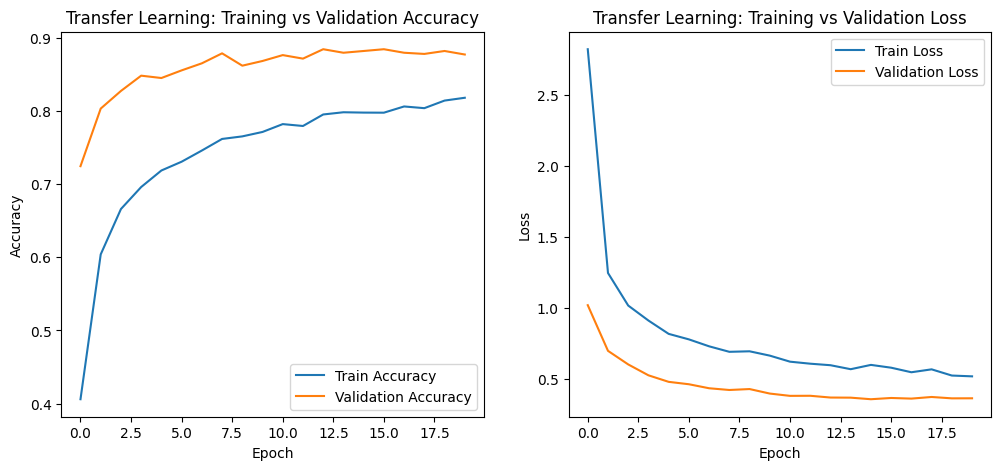

In [42]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_tl.history['accuracy'], label='Train Accuracy')
plt.plot(history_tl.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Transfer Learning: Training vs Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_tl.history['loss'], label='Train Loss')
plt.plot(history_tl.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Transfer Learning: Training vs Validation Loss')
plt.legend()
plt.show()


In [43]:
results_tl = model_tl.evaluate(val_ds_img_diff)
print(f"Validation Loss: {results_tl[0]:.4f}, Validation Accuracy: {results_tl[1]:.4f}")

y_true = []
y_pred = []
for images, labels in val_ds_img_diff:
    preds = model_tl.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
print(classification_report(y_true, y_pred, target_names=class_names))

macro_f1_tl = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score: {macro_f1_tl:.4f}")


39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8819 - loss: 0.3575
Validation Loss: 0.3575, Validation Accuracy: 0.8819
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/ste

Total time: 4min 51s

Early stopping triggered at epoch 20 with best epoch 15. Every class seems to be performing well even the ones that were weak in other models. 

val accuracy 88% macro f1 0.8784 which is the best yet however thats to be expected.

## Fine tune 

will unfreeze some of the top layers of the pre trained VGG16 base. only last 4 layers are unfrozen to make small adjustements to the higher level features. this preserves the general low level features learned on ImageNet

In [49]:
base_model.trainable = True                                                                                                                                                      
for layer in base_model.layers[:-4]:
    layer.trainable = False  

will use low learning rate as brief wants, this is to avoid large weight updates that could destroy pre trained features. 

In [50]:
model_tl.compile(                                                                                                                                                                
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),                                                                                                                      
    loss='sparse_categorical_crossentropy',                                                                                                                                      
    metrics=['accuracy']                                                                                                                                                         
)  

In [51]:
%%time                                                                                                                                                                           
history_ft = model_tl.fit(                                                                                                                                                       
    train_ds_img_diff,                                                                                                                                                           
    validation_data=val_ds_img_diff,
    epochs=15,                                                                                                                                                                    
    class_weight=class_weight,
    callbacks=get_callbacks()                                                                                                                                                    
)   

Epoch 1/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step - accuracy: 0.8901 - loss: 0.3095 - val_accuracy: 0.9092 - val_loss: 0.2817
Epoch 2/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.8966 - loss: 0.2869 - val_accuracy: 0.9116 - val_loss: 0.2762
Epoch 3/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.9069 - loss: 0.2489 - val_accuracy: 0.9165 - val_loss: 0.2755
Epoch 4/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.9098 - loss: 0.2417 - val_accuracy: 0.9157 - val_loss: 0.2720
Epoch 5/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.9189 - loss: 0.2166 - val_accuracy: 0.9237 - val_loss: 0.2710
Epoch 6/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.9231 - loss: 0.2086 - val_accuracy: 0.9189 - val_loss: 0.2765
Epoch 7/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.9313 - loss: 0.1877 - val_accuracy: 0.9229 - val_loss: 0.2779
Epoch 8/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.9352 - loss: 0.1691 - 

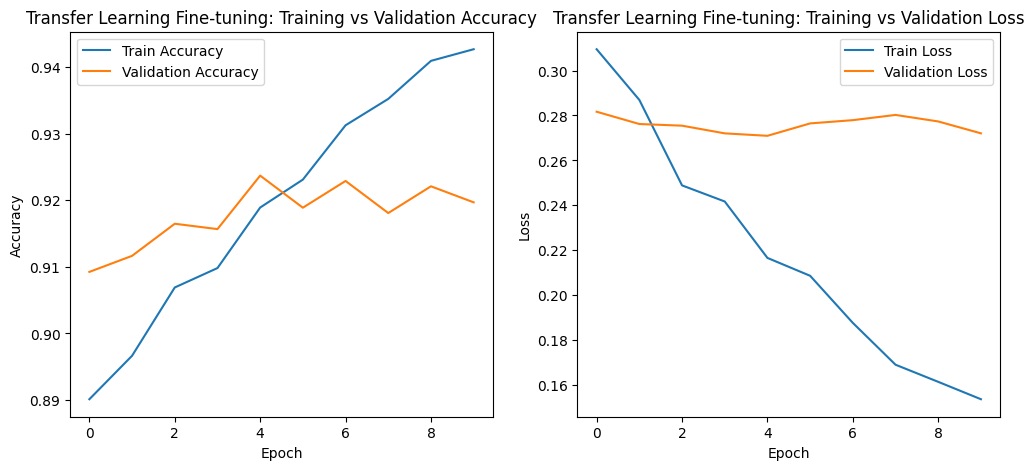

In [52]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_ft.history['accuracy'], label='Train Accuracy')
plt.plot(history_ft.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Transfer Learning Fine-tuning: Training vs Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_ft.history['loss'], label='Train Loss')
plt.plot(history_ft.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Transfer Learning Fine-tuning: Training vs Validation Loss')
plt.legend()
plt.show()


In [53]:
results_ft = model_tl.evaluate(val_ds_img_diff)
print(f"Validation Loss: {results_ft[0]:.4f}, Validation Accuracy: {results_ft[1]:.4f}")

y_true = []
y_pred = []
for images, labels in val_ds_img_diff:
    preds = model_tl.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
print(classification_report(y_true, y_pred, target_names=class_names))

macro_f1_ft = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score: {macro_f1_ft:.4f}")


39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9237 - loss: 0.2710
Validation Loss: 0.2710, Validation Accuracy: 0.9237
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/ste

Total time: 2min 11s

Epoch 10: early stopping and best epoch was epoch 5. 

val accuracy 92.4% and macro f1 0.9167 

Best model so far. The train accuracy kept climbing while val accuracy went fluctuated so the model must have learned everything it could from fine tuning. 

# Final evaluation

The fine tuned VGG16 is the clear winner with the best macro f1 score of 0.9167. It was able to fit nicely to the data and performed well on all classes of the dataset. 

now I will evaluate the model on the test set 

In [54]:
results_test = model_tl.evaluate(test_ds_img_diff)                                                                                                                               
print(f"Test Loss: {results_test[0]:.4f}, Test Accuracy: {results_test[1]:.4f}")                                                                                                 
                                                                                                                                                                                
y_true_test = []                                                                                                                                                                 
y_pred_test = []                                                                                                                                                                 
for images, labels in test_ds_img_diff:
    preds = model_tl.predict(images)                                                                                                                                             
    y_true_test.extend(labels.numpy())
    y_pred_test.extend(np.argmax(preds, axis=1))                                                                                                                                 
                                                                                                                                                                                
print(classification_report(y_true_test, y_pred_test, target_names=class_names))
                                                                                                                                                                                
macro_f1_test = f1_score(y_true_test, y_pred_test, average='macro')                                                                                                              
print(f"Macro F1 Score: {macro_f1_test:.4f}")

76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9157 - loss: 0.2774
Test Loss: 0.2774, Test Accuracy: 0.9157
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━

decent test results, very close to the validation results which confirms the model generalises well. 

weakest classes are trash and plastic which make sense because trash is the smallest class and plastic can look similar to other materials. 

test accuracy 91.6% and macro f1 0.9074

now to take inference measurement on the test set, basically how long it takes the model to make predictions on unseen data

In [55]:
import timeit                                                                                                                                                                    
   
def predict_test_set():                                                                                                                                                          
    for images, labels in test_ds_img_diff:
        model_tl.predict(images, verbose=0)                                                                                                                                      
                                                                                                                                                                                
inference_time = timeit.timeit(predict_test_set, number=1)                                                                                                                       
print(f"Inference time on test set ({len(y_true_test)} images): {inference_time:.2f}s")                                                                                          
print(f"Average per image: {inference_time / len(y_true_test) * 1000:.2f}ms")  

Inference time on test set (2432 images): 5.34s
Average per image: 2.20ms


The model takes 5.34s to classify the full test set of 2432 images, averaging 2.20ms per image. This is fast enough for real-time classification.

now ill use a confusion matrix to show where the model is making mistakes and which classes are being confused with each other. 

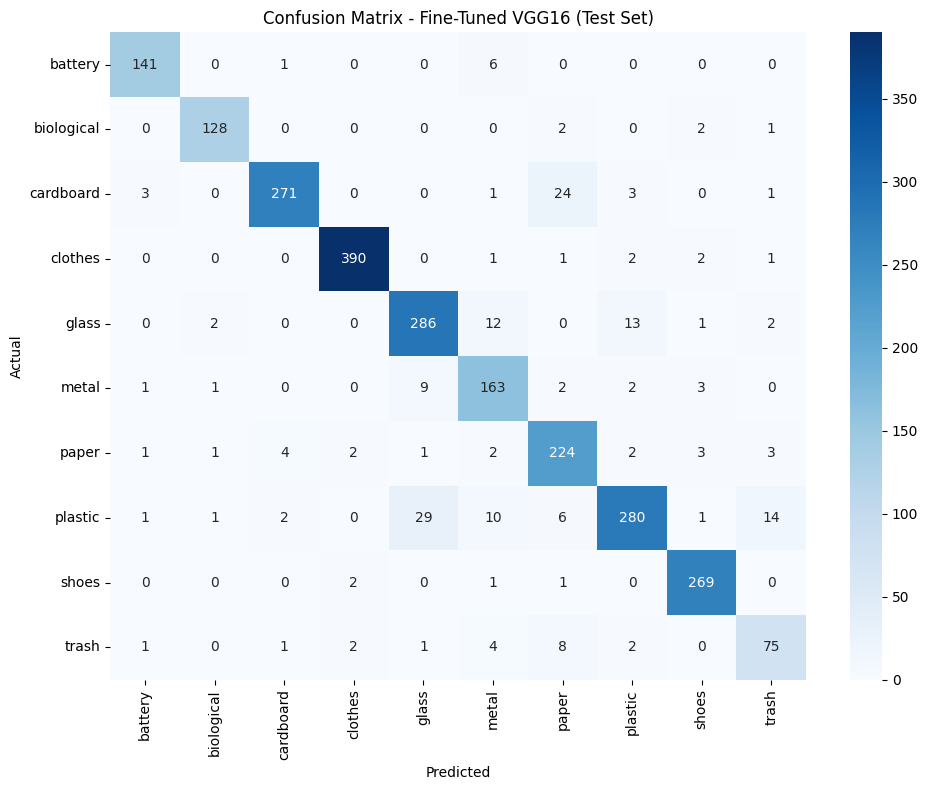

In [56]:
from sklearn.metrics import confusion_matrix                                                                                                                                     
import seaborn as sns
                                                                                                                                                                                
cm = confusion_matrix(y_true_test, y_pred_test)                                                                                                                                  
                                                                                                                                                                                
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)                                                                                                                    
plt.xlabel('Predicted')
plt.ylabel('Actual')                                                                                                                                                             
plt.title('Confusion Matrix - Fine-Tuned VGG16 (Test Set)')                                                                                                                      
plt.tight_layout()                                                                                                                                                               
plt.show()   

from the confusion matrix we can see that plastic and glass are being mistaken for each other which is fair enough as both are mainly see through. it also gets confused between paper and cardboard which again is understandable. There are a few mistakes that are a bit strange but it may have been the way the image was taken, for example to mistake a battery with paper is an interesting one. 

now compare each model 

In [62]:
print(f"{'Model':<30} {'Val Acc':>10} {'Macro F1':>10}")                                                                                                                         
print("-" * 52)                                                                                                                                                                  
models = [                                                                                                                                                                       
    ("M1: Shallow (2 conv)", 0.5398, 0.5375),                                                                                                                                    
    ("M2: Deep (4 conv)", 0.6627, 0.6524),                                                                                                                                       
    ("M3: Deep + BN + Dropout", 0.5261, 0.5215),                                                                                                                                 
    ("M4: Deep + BN only", 0.6137, 0.6054),
    ("M5: Deep + Dropout", 0.7454, 0.7443),                                                                                                                                      
    ("M6: Deep + Dropout + Aug", 0.6546, 0.6485),
    ("M5 Greyscale", 0.6851, 0.6770),                                                                                                                                            
    ("M5 at 224x224", 0.7414, 0.7333),                                                                                                                                           
    ("VGG16 Transfer Learning", 0.8819, 0.8784),
    ("VGG16 Fine-Tuned", 0.9237, 0.9167),                                                                                                                                        
]                                                                                                                                                                                
for name, acc, f1 in models:
    print(f"{name:<30} {acc:>10.4f} {f1:>10.4f}")                                                                                                                                
print("-" * 52)                                                                                                                                                                  
print(f"{'Best (Test Set):':<30} {0.9157:>10.4f} {0.9074:>10.4f}")

Model                             Val Acc   Macro F1
----------------------------------------------------
M1: Shallow (2 conv)               0.5398     0.5375
M2: Deep (4 conv)                  0.6627     0.6524
M3: Deep + BN + Dropout            0.5261     0.5215
M4: Deep + BN only                 0.6137     0.6054
M5: Deep + Dropout                 0.7454     0.7443
M6: Deep + Dropout + Aug           0.6546     0.6485
M5 Greyscale                       0.6851     0.6770
M5 at 224x224                      0.7414     0.7333
VGG16 Transfer Learning            0.8819     0.8784
VGG16 Fine-Tuned                   0.9237     0.9167
----------------------------------------------------
Best (Test Set):                   0.9157     0.9074


now get the paramater count for each model 

In [75]:
print(f"{'Model':<30} {'Total Params':>15} {'Trainable':>15}")                                                                                                                   
print("-" * 62)                                                                                                                                                                  
param_models = [                                                                                                                                                                 
    ("M1: Shallow (2 conv)", model_v1),                                                                                                                                          
    ("M2: Deep (4 conv)", model_v2),
    ("M3: Deep + BN + Dropout", model_v3),                                                                                                                                       
    ("M4: Deep + BN only", model_v4),
    ("M5: Deep + Dropout", model_v5),                                                                                                                                            
    ("M6: Deep + Dropout + Aug", model_v6),
    ("M5 Greyscale", model_v5_grey),                                                                                                                                             
    ("M5 at 224x224", model_v5_img_size_diff),
    ("VGG16 Transfer Learning", model_tl),                                                                                                                                       
]               
for name, model in param_models:                                                                                                                                                 
    total = model.count_params()
    trainable = sum(p.numpy().size for p in model.trainable_weights)                                                                                                             
    print(f"{name:<30} {total:>15,} {trainable:>15,}")  

Model                             Total Params       Trainable
--------------------------------------------------------------
M1: Shallow (2 conv)                    24,202          24,202
M2: Deep (4 conv)                      405,514         405,514
M3: Deep + BN + Dropout                407,434         406,474
M4: Deep + BN only                     407,434         406,474
M5: Deep + Dropout                     405,514         405,514
M6: Deep + Dropout + Aug               405,514         405,514
M5 Greyscale                           404,938         404,938
M5 at 224x224                          405,514         405,514
VGG16 Transfer Learning             14,748,170       7,112,906


now get the training time of each model 

In [85]:
print(f"{'Model':<30} {'Training Time':>15}")                                                                                                                                    
print("-" * 47)                                                                                                                                                                  
training_times = [                                                                                                                                                               
    ("M1: Shallow (2 conv)", "7min 33s"),                                                                                                                                        
    ("M2: Deep (4 conv)", "6min 17s"),                                                                                                                                           
    ("M3: Deep + BN + Dropout", "3min 21s"),                                                                                                                                     
    ("M4: Deep + BN only", "4min 3s"),                                                                                                                                           
    ("M5: Deep + Dropout", "9min 55s"),                                                                                                                                          
    ("M6: Deep + Dropout + Aug", "10min 1s"),                                                                                                                                    
    ("M5 Greyscale", "14min 5s"),                                                                                                                                                
    ("M5 at 224x224", "3min 57s"),                                                                                                                                               
    ("VGG16 Transfer Learning", "4min 51s"),
    ("VGG16 Fine-Tuned", "2min 11s"),                                                                                                                                            
]               
for name, time in training_times:                                                                                                                                                
    print(f"{name:<30} {time:>15}") 

Model                            Training Time
-----------------------------------------------
M1: Shallow (2 conv)                  7min 33s
M2: Deep (4 conv)                     6min 17s
M3: Deep + BN + Dropout               3min 21s
M4: Deep + BN only                     4min 3s
M5: Deep + Dropout                    9min 55s
M6: Deep + Dropout + Aug              10min 1s
M5 Greyscale                          14min 5s
M5 at 224x224                         3min 57s
VGG16 Transfer Learning               4min 51s
VGG16 Fine-Tuned                      2min 11s


greyscale took the longest despite fewer params  
224x224 was twice the speed of 384x384 with almost the same accuracy  
fine tuning was the fastest since it only ran 10 epochs with early stopping. 

# Test to see if the model can identify my 4 photos

In [87]:
from tensorflow.keras.utils import load_img, img_to_array
from PIL import ImageOps    

In [88]:
own_image_dir = "four-garbage-images"                                                                                                                                            
own_images = sorted(os.listdir(own_image_dir))

Just print them normal size to verify 

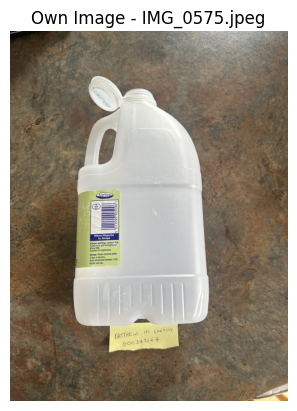

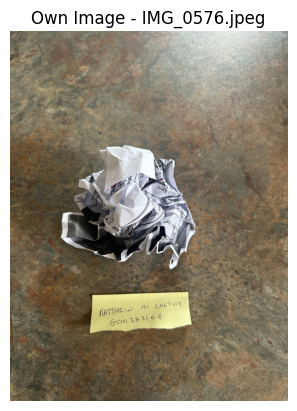

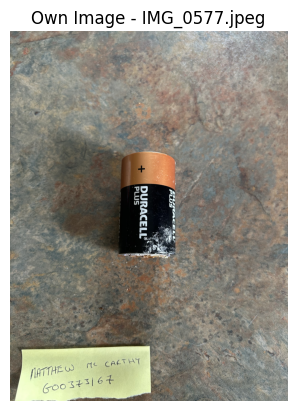

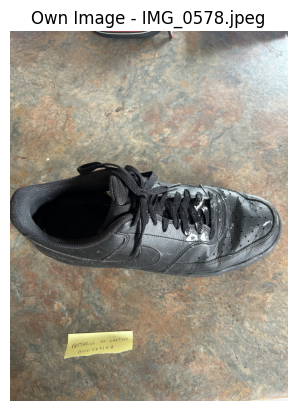

In [89]:
for img_name in own_images:                                                                                                                                                      
    img_path = os.path.join(own_image_dir, img_name)
    img = load_img(img_path)                                                                                                                                                     
    img = ImageOps.exif_transpose(img)
    plt.imshow(img)                                                                                                                                                              
    plt.title(f"Own Image - {img_name}")                                                                                                                                         
    plt.axis('off')
    plt.show()    

Now I will load each image at 224x224 for the VGG16 model, apply preprocessing and then show the prediction with confidence. 

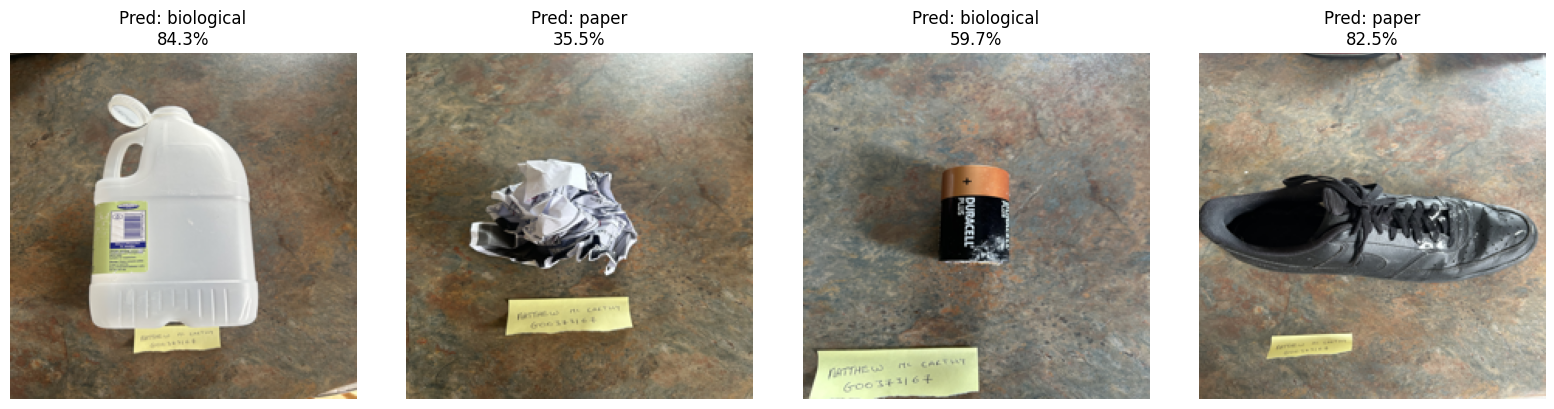

In [90]:
plt.figure(figsize=(16, 4))                                                                                                                                                      
for i, img_name in enumerate(own_images):
    img_path = os.path.join(own_image_dir, img_name)                                                                                                                             
    img = load_img(img_path)
    img = ImageOps.exif_transpose(img)                                                                                                                                           
    img = img.resize((224, 224))                                                                                                                                                 
    img_array = img_to_array(img)
    img_preprocessed = preprocess_input(img_array.copy())                                                                                                                        
    img_batch = np.expand_dims(img_preprocessed, axis=0)
                                                                                                                                                                                
    pred = model_tl.predict(img_batch, verbose=0)
    predicted_class = class_names[np.argmax(pred)]                                                                                                                               
    confidence = np.max(pred) * 100                                                                                                                                              

    plt.subplot(1, 4, i + 1)                                                                                                                                                     
    plt.imshow(img)
    plt.title(f"Pred: {predicted_class}\n{confidence:.1f}%")                                                                                                                     
    plt.axis('off')
                                                                                                                                                                                
plt.tight_layout()
plt.show()

results were poor, only 1/4 correct. The model predicted paper correctly but was very unsure (35.5%). It predicted the plastic milk carton as biological (84.3%), the battery as biological (59.7%) and the shoe as paper (82.5%). The images are taken too far away with too much background so ill retake them closer to the items.

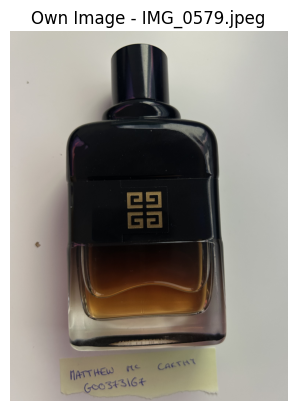

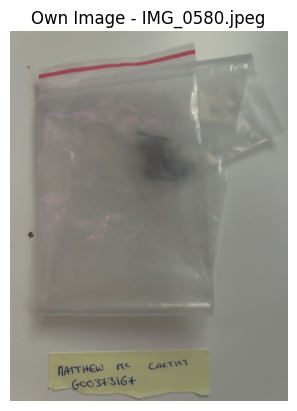

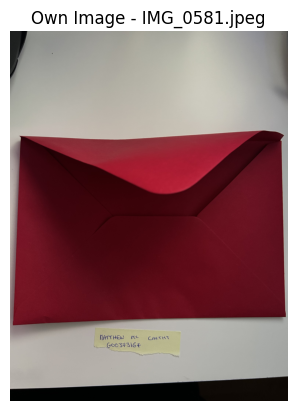

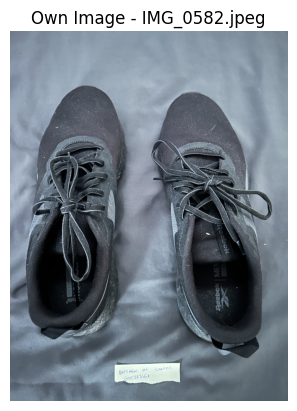

In [91]:
own_image_dir = "four-garbage-images-closer"                                                                                                                                            
own_images = sorted(os.listdir(own_image_dir))
                                                                                                                                                     
                  
for img_name in own_images:                                                                                                                                                      
    img_path = os.path.join(own_image_dir, img_name)
    img = load_img(img_path)                                                                                                                                                     
    img = ImageOps.exif_transpose(img)
    plt.imshow(img)                                                                                                                                                              
    plt.title(f"Own Image - {img_name}")                                                                                                                                         
    plt.axis('off')
    plt.show()    

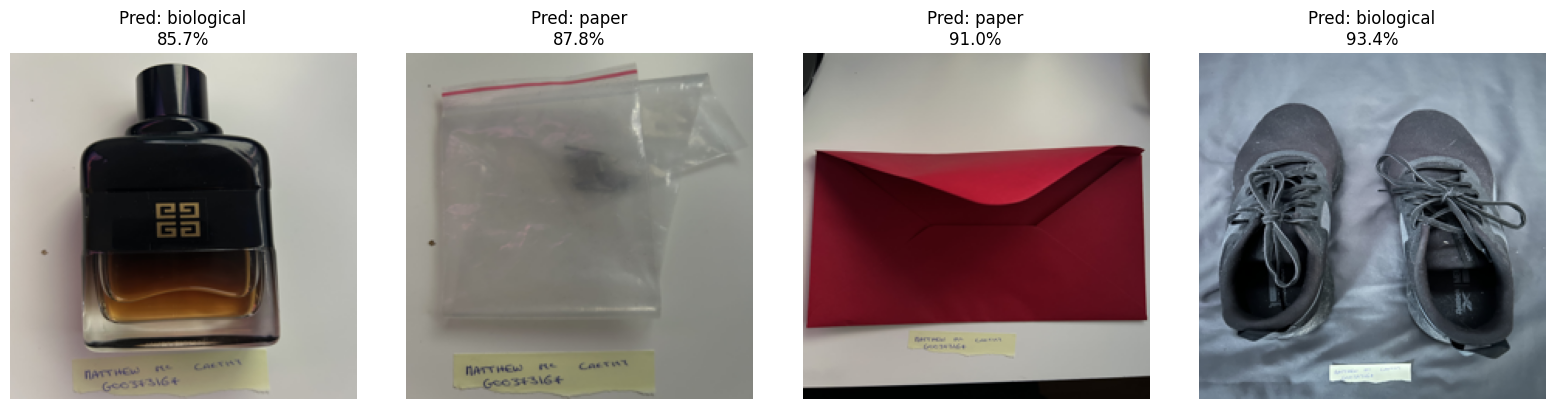

In [92]:
plt.figure(figsize=(16, 4))                                                                                                                                                      
for i, img_name in enumerate(own_images):
    img_path = os.path.join(own_image_dir, img_name)                                                                                                                             
    img = load_img(img_path)
    img = ImageOps.exif_transpose(img)                                                                                                                                           
    img = img.resize((224, 224))                                                                                                                                                 
    img_array = img_to_array(img)
    img_preprocessed = preprocess_input(img_array.copy())                                                                                                                        
    img_batch = np.expand_dims(img_preprocessed, axis=0)
                                                                                                                                                                                
    pred = model_tl.predict(img_batch, verbose=0)
    predicted_class = class_names[np.argmax(pred)]                                                                                                                               
    confidence = np.max(pred) * 100                                                                                                                                              

    plt.subplot(1, 4, i + 1)                                                                                                                                                     
    plt.imshow(img)
    plt.title(f"Pred: {predicted_class}\n{confidence:.1f}%")                                                                                                                     
    plt.axis('off')
                                                                                                                                                                                
plt.tight_layout()
plt.show()

closer photos also got 1/4 correct however the one it did get right (paper) was much more confident at 91% compared to 35.5% in the first attempt. The model seems to be heavily biased towards predicting biological and paper on my photos. It predicted the glass perfume bottle as biological (85.7%), the plastic bag as paper (87.8%) and the shoes as biological (93.4%).

comparing to the confusion matrix, plastic predicted as biological has only 1 case, glass as biological has 2, shoes as biological has 0 and plastic as paper has 6. so these are not common confusions for the model which suggests the misclassifications are due to photo conditions like lighting and background rather than systematic model weakness. 